# Customer Feedback Classification using BERT and RoBERTa with Sequential Context Learning

**Dataset:** `Dataset-SA.csv`

This notebook builds four experiments:
- BERT + current review
- RoBERTa + current review
- BERT + constructed sequential context
- RoBERTa + constructed sequential context

**Important:** The uploaded dataset has no real conversation/turn ID. Therefore, sequential context is constructed from earlier reviews of the **same product**, following their row order. This is a context-window experiment, not a true multi-turn conversation model.


## 1. Install libraries

In [2]:
!pip -q install -U transformers datasets accelerate evaluate scikit-learn seaborn gradio

## 2. Imports and GPU check

In [3]:
import os, gc, inspect, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, set_seed

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.14.0+cpu
GPU available: False


## 3. Upload `Dataset-SA.csv`

In [5]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "Dataset-SA.csv"

if not DATA_PATH.exists() and Path("/content/Dataset-SA.csv").exists():
    DATA_PATH = Path("/content/Dataset-SA.csv")

if not DATA_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = Path.cwd() / next(iter(uploaded))
    except ImportError as exc:
        raise FileNotFoundError(
            "Dataset-SA.csv was not found in the notebook folder or /content."
        ) from exc

OUTPUT_DIR = PROJECT_DIR / "customer_feedback_project"
MODEL_DIR = OUTPUT_DIR / "models"
print("Using:", DATA_PATH.resolve())


Using: C:\Users\rehan\TYBScDS\TDDS018B_NLP\NLP_PRJCT\Dataset-SA.csv


## 4. Load and inspect dataset

In [6]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nSentiments:\n", df["Sentiment"].value_counts(dropna=False))


Shape: (205052, 6)
Columns: ['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral



Missing values:
 product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Duplicates: 34375

Sentiments:
 Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


## 5. Clean data

In [7]:
df = df.copy()
df["Review"] = df["Review"].fillna("").astype(str)
df["Summary"] = df["Summary"].fillna("").astype(str)
df["product_name"] = df["product_name"].fillna("Unknown Product").astype(str)
df["Sentiment"] = df["Sentiment"].fillna("").astype(str).str.strip().str.lower()

df["text"] = df["Review"].where(df["Review"].str.strip().ne(""), df["Summary"])
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

df = df[df["Sentiment"].isin(["positive","negative","neutral"])]
df = df[df["text"].str.len() > 0]
df = df.drop_duplicates(subset=["product_name","text","Sentiment"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df["Sentiment"].value_counts())


Cleaned shape: (50276, 7)
Sentiment
positive    31352
negative    12576
neutral      6348
Name: count, dtype: int64


## 6. EDA

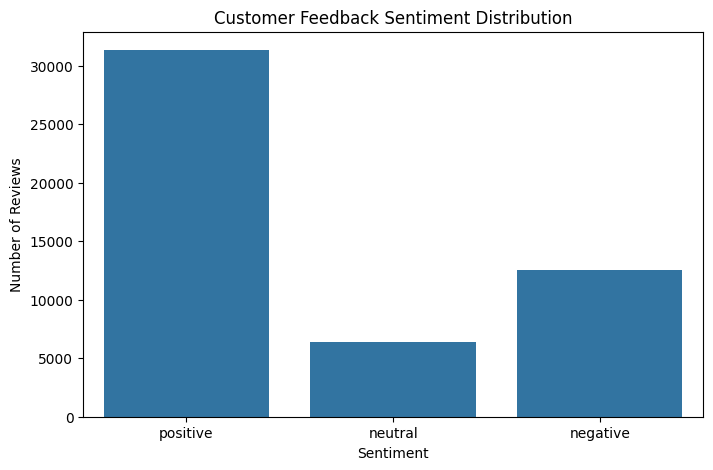

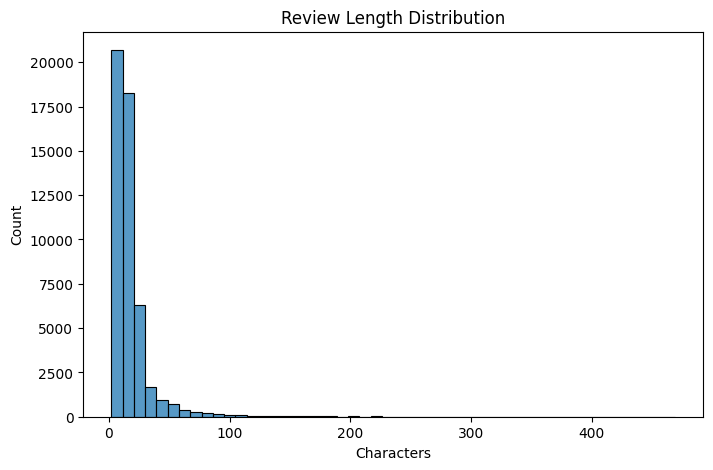

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Sentiment", order=["positive","neutral","negative"])
plt.title("Customer Feedback Sentiment Distribution")
plt.xlabel("Sentiment"); plt.ylabel("Number of Reviews")
plt.show()

df["text_length"] = df["text"].str.len()
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Characters"); plt.ylabel("Count")
plt.show()


## 7. Label encoding

In [9]:
label2id = {"negative":0, "neutral":1, "positive":2}
id2label = {0:"NEGATIVE", 1:"NEUTRAL", 2:"POSITIVE"}
df["label"] = df["Sentiment"].map(label2id).astype(int)
print(label2id)
display(df[["Sentiment","label"]].drop_duplicates().sort_values("label"))


{'negative': 0, 'neutral': 1, 'positive': 2}


,Sentiment,label
3,negative,0
4,neutral,1
0,positive,2


## 8. Create sequential context

Because there is no conversation ID, product name is used as the grouping key. For every review, up to the previous two reviews of the same product are added as context.

In [10]:
CONTEXT_SIZE = 2
df = df.reset_index(drop=True)

context_by_index = {}
for product, group in df.groupby("product_name", sort=False):
    history = []
    for index, row in group.iterrows():
        context_by_index[index] = " [CTX] ".join(history[-CONTEXT_SIZE:])
        history.append(row["text"])

df["context"] = df.index.map(context_by_index).fillna("")
df["context_input"] = np.where(
    df["context"].str.len() > 0,
    df["context"] + " [CURRENT] " + df["text"],
    df["text"]
)

display(df[["product_name","context","text","context_input","Sentiment"]].head(10))


,product_name,context,text,context_input,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,,super!,super!,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,super!,awesome,super! [CURRENT] awesome,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,super! [CTX] awesome,fair,super! [CTX] awesome [CURRENT] fair,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,awesome [CTX] fair,useless product,awesome [CTX] fair [CURRENT] useless product,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,fair [CTX] useless product,fair,fair [CTX] useless product [CURRENT] fair,neutral
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,useless product [CTX] fair,highly recommended,useless product [CTX] fair [CURRENT] highly re...,positive
6,Candes 12 L Room/Personal Air Cooler??????(Whi...,fair [CTX] highly recommended,nice,fair [CTX] highly recommended [CURRENT] nice,positive
7,Candes 12 L Room/Personal Air Cooler??????(Whi...,highly recommended [CTX] nice,unsatisfactory,highly recommended [CTX] nice [CURRENT] unsati...,negative
8,Candes 12 L Room/Personal Air Cooler??????(Whi...,nice [CTX] unsatisfactory,worth the money,nice [CTX] unsatisfactory [CURRENT] worth the ...,positive
9,Candes 60 L Room/Personal Air Cooler??????(Whi...,,great product,great product,positive


## 9. Train / validation / test split

In [11]:
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (40220, 11)
Validation: (5028, 11)
Test: (5028, 11)


## 10. Colab safety setting

The original dataset is large. For a phone/Free Colab, start with 20,000 training samples. Once the notebook works, you can set these values to `None` or larger values and retrain.


In [16]:
MAX_TRAIN_SAMPLES = 20000
MAX_VAL_SAMPLES = 500
MAX_TEST_SAMPLES = 500

def stratified_cap(data, n):
    if n is None or len(data) <= n:
        return data.copy()
    out, _ = train_test_split(data, train_size=n, stratify=data["label"], random_state=SEED)
    return out.reset_index(drop=True)

train_run = stratified_cap(train_df, MAX_TRAIN_SAMPLES)
val_run = stratified_cap(val_df, MAX_VAL_SAMPLES)
test_run = stratified_cap(test_df, MAX_TEST_SAMPLES)
print("Run sizes:", len(train_run), len(val_run), len(test_run))


Run sizes: 20000 500 500


## 11. Training and evaluation helpers

In [17]:
def make_hf_dataset(data, text_col):
    x = data[[text_col, "label"]].rename(columns={text_col:"text"}).copy()
    return Dataset.from_pandas(x, preserve_index=False)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p,r,f1,_ = precision_recall_fscore_support(labels,preds,average="weighted",zero_division=0)
    return {"accuracy":accuracy_score(labels,preds),"precision":p,"recall":r,"f1":f1}

def train_model(model_name, train_data, val_data, text_col, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tr = make_hf_dataset(train_data,text_col)
    va = make_hf_dataset(val_data,text_col)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=256)

    tr = tr.map(tok, batched=True, remove_columns=["text"])
    va = va.map(tok, batched=True, remove_columns=["text"])

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3, id2label=id2label, label2id=label2id
    )

    training_kwargs = dict(
        output_dir=str(output_dir),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )
    strategy_parameter = "eval_strategy" if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters else "evaluation_strategy"
    training_kwargs[strategy_parameter] = "epoch"
    args = TrainingArguments(**training_kwargs)

    trainer = Trainer(
        model=model, args=args, train_dataset=tr, eval_dataset=va,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics
    )
    trainer.train()
    return tokenizer, model, trainer

def evaluate_model(trainer, data, text_col, tokenizer):
    ds = make_hf_dataset(data,text_col)
    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=256)
    ds = ds.map(tok, batched=True, remove_columns=["text"])
    out = trainer.predict(ds)
    preds = np.argmax(out.predictions,axis=-1)
    labels = np.array(data["label"])
    p,r,f1,_ = precision_recall_fscore_support(labels,preds,average="weighted",zero_division=0)
    metrics = {"accuracy":accuracy_score(labels,preds),"precision":p,"recall":r,"f1":f1}
    return metrics, labels, preds


## 12. BERT — current review only

In [18]:
                                            bert_tok, bert_model, bert_trainer = train_model(
    "bert-base-uncased", train_run, val_run, "text", MODEL_DIR / "bert_current"
)
bert_current_metrics, bert_current_y, bert_current_pred = evaluate_model(
    bert_trainer, test_run, "text", bert_tok
)
print(bert_current_metrics)


IndentationError: unexpected indent (3042561603.py, line 1)

## 13. RoBERTa — current review only

In [ ]:
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

roberta_tok, roberta_model, roberta_trainer = train_model(
    "roberta-base", train_run, val_run, "text", MODEL_DIR / "roberta_current"
)
roberta_current_metrics, roberta_current_y, roberta_current_pred = evaluate_model(
    roberta_trainer, test_run, "text", roberta_tok
)
print(roberta_current_metrics)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.865190,0.857210,0.650000,0.535361,0.650000,0.587056
2,0.876553,0.859918,0.650000,0.534226,0.650000,0.584739


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

{'accuracy': 0.5870646766169154, 'precision': 0.48702677090736796, 'recall': 0.5870646766169154, 'f1': 0.5322235787942613}


## 14. BERT — sequential context

In [ ]:
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

bert_ctx_tok, bert_ctx_model, bert_ctx_trainer = train_model(
    "bert-base-uncased", train_run, val_run, "context_input", MODEL_DIR / "bert_context"
)
bert_context_metrics, bert_context_y, bert_context_pred = evaluate_model(
    bert_ctx_trainer, test_run, "context_input", bert_ctx_tok
)
print(bert_context_metrics)


Map:   0%|          | 0/1602 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.847042,0.857051,0.635000,0.533547,0.635000,0.577256
2,0.842590,0.853557,0.665000,0.549716,0.665000,0.601775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

{'accuracy': 0.6368159203980099, 'precision': 0.5245758161866475, 'recall': 0.6368159203980099, 'f1': 0.5750972826157924}


## 15. RoBERTa — sequential context

In [ ]:
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

roberta_ctx_tok, roberta_ctx_model, roberta_ctx_trainer = train_model(
    "roberta-base", train_run, val_run, "context_input", MODEL_DIR / "roberta_context"
)
roberta_context_metrics, roberta_context_y, roberta_context_pred = evaluate_model(
    roberta_ctx_trainer, test_run, "context_input", roberta_ctx_tok
)
print(roberta_context_metrics)


Map:   0%|          | 0/1602 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.882088,0.909525,0.640000,0.530480,0.640000,0.579796
2,0.842143,0.870062,0.660000,0.544357,0.660000,0.596625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

{'accuracy': 0.6318407960199005, 'precision': 0.5194482134780642, 'recall': 0.6318407960199005, 'f1': 0.5697252580074832}


## 16. Classification reports

In [18]:
reports = [
    ("BERT / Current", bert_current_y, bert_current_pred),
    ("RoBERTa / Current", roberta_current_y, roberta_current_pred),
    ("BERT / Context", bert_context_y, bert_context_pred),
    ("RoBERTa / Context", roberta_context_y, roberta_context_pred)
]
for name,y,pred in reports:
    print("\n====",name,"====")
    print(classification_report(y,pred,target_names=["negative","neutral","positive"],digits=4))



==== BERT / Current ====
              precision    recall  f1-score   support

    negative     0.5362    0.6271    0.5781        59
     neutral     0.0000    0.0000    0.0000        35
    positive     0.6515    0.8037    0.7197       107

    accuracy                         0.6119       201
   macro avg     0.3959    0.4770    0.4326       201
weighted avg     0.5042    0.6119    0.5528       201


==== RoBERTa / Current ====
              precision    recall  f1-score   support

    negative     0.4933    0.6271    0.5522        59
     neutral     0.0000    0.0000    0.0000        35
    positive     0.6429    0.7570    0.6953       107

    accuracy                         0.5871       201
   macro avg     0.3787    0.4614    0.4158       201
weighted avg     0.4870    0.5871    0.5322       201


==== BERT / Context ====
              precision    recall  f1-score   support

    negative     0.5735    0.6610    0.6142        59
     neutral     0.0000    0.0000    0.0000     

## 17. Confusion matrices

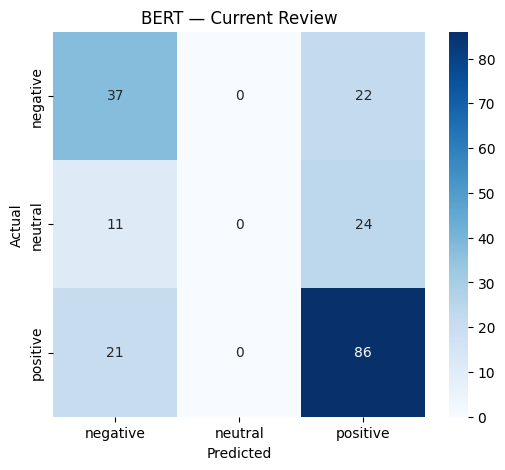

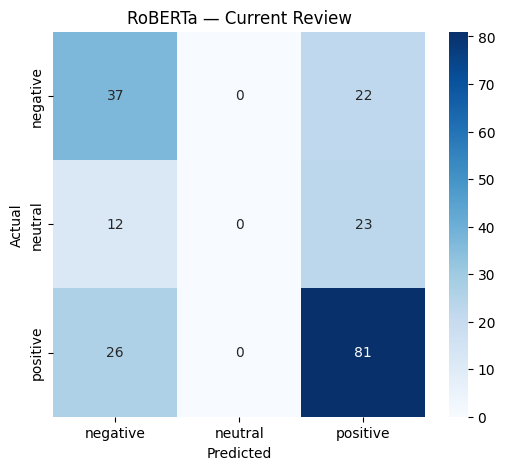

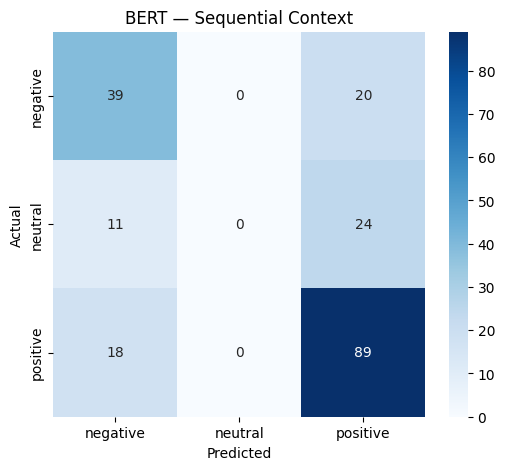

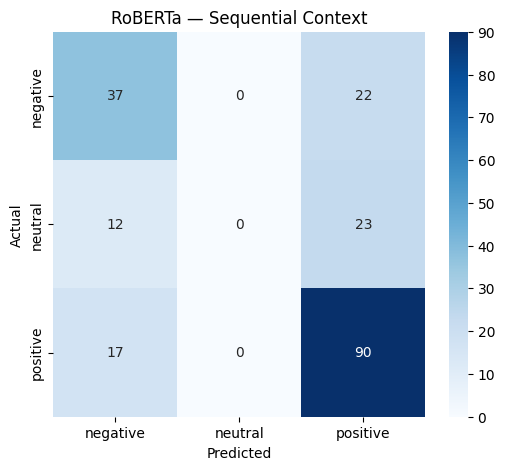

In [19]:
def plot_cm(y,pred,title):
    cm = confusion_matrix(y,pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=["negative","neutral","positive"],
                yticklabels=["negative","neutral","positive"])
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

plot_cm(bert_current_y,bert_current_pred,"BERT — Current Review")
plot_cm(roberta_current_y,roberta_current_pred,"RoBERTa — Current Review")
plot_cm(bert_context_y,bert_context_pred,"BERT — Sequential Context")
plot_cm(roberta_context_y,roberta_context_pred,"RoBERTa — Sequential Context")


## 18. Model comparison

,Model,Input,accuracy,precision,recall,f1
0,BERT,Sequential Context,0.636816,0.524576,0.636816,0.575097
1,RoBERTa,Sequential Context,0.631841,0.519448,0.631841,0.569725
2,BERT,Current Review,0.611940,0.504228,0.611940,0.552804
3,RoBERTa,Current Review,0.587065,0.487027,0.587065,0.532224


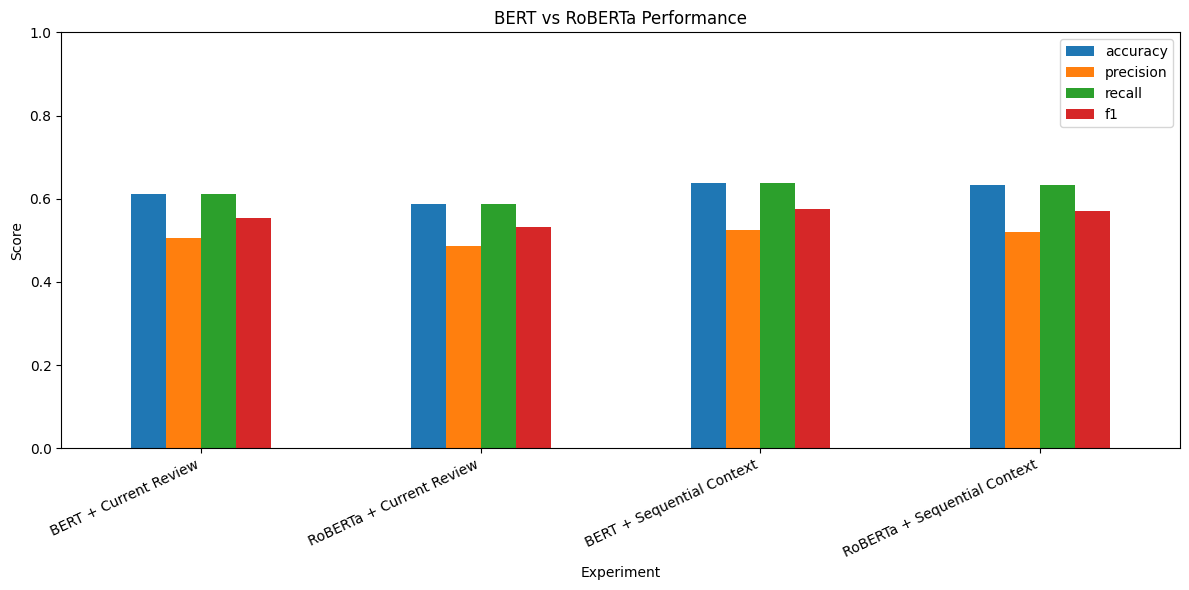

In [20]:
results = pd.DataFrame([
    {"Model":"BERT","Input":"Current Review",**bert_current_metrics},
    {"Model":"RoBERTa","Input":"Current Review",**roberta_current_metrics},
    {"Model":"BERT","Input":"Sequential Context",**bert_context_metrics},
    {"Model":"RoBERTa","Input":"Sequential Context",**roberta_context_metrics},
])
display(results.sort_values("f1",ascending=False).reset_index(drop=True))

plot_df = results.copy()
plot_df["Experiment"] = plot_df["Model"] + " + " + plot_df["Input"]
plot_df.set_index("Experiment")[["accuracy","precision","recall","f1"]].plot(kind="bar",figsize=(12,6))
plt.ylim(0,1); plt.title("BERT vs RoBERTa Performance"); plt.ylabel("Score")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.show()


## 19. Context improvement

In [21]:
comparison = pd.DataFrame({
    "Model":["BERT","RoBERTa"],
    "Current_F1":[bert_current_metrics["f1"],roberta_current_metrics["f1"]],
    "Context_F1":[bert_context_metrics["f1"],roberta_context_metrics["f1"]]
})
comparison["F1_Improvement"] = comparison["Context_F1"] - comparison["Current_F1"]
display(comparison)


,Model,Current_F1,Context_F1,F1_Improvement
0,BERT,0.552804,0.575097,0.022294
1,RoBERTa,0.532224,0.569725,0.037502


## 20. Automatic best-model selection and prediction

In [ ]:
best_idx = results["f1"].idxmax()
best = results.loc[best_idx]
print("Best experiment:", best.to_dict())

if best["Model"]=="BERT" and best["Input"]=="Current Review":
    BEST_MODEL,BEST_TOKENIZER,USE_CONTEXT = bert_model,bert_tok,False
elif best["Model"]=="RoBERTa" and best["Input"]=="Current Review":
    BEST_MODEL,BEST_TOKENIZER,USE_CONTEXT = roberta_model,roberta_tok,False
elif best["Model"]=="BERT":
    BEST_MODEL,BEST_TOKENIZER,USE_CONTEXT = bert_ctx_model,bert_ctx_tok,True
else:
    BEST_MODEL,BEST_TOKENIZER,USE_CONTEXT = roberta_ctx_model,roberta_ctx_tok,True

device = get_device()
BEST_MODEL.to(device)
BEST_MODEL.eval()

def predict_sentiment(review, context=""):
    text = review.strip()
    if USE_CONTEXT and context.strip():
        text = context.strip() + " [CURRENT] " + text
    inputs = BEST_TOKENIZER(text,return_tensors="pt",truncation=True,max_length=256)
    inputs = {k:v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        probs = torch.softmax(BEST_MODEL(**inputs).logits,dim=-1)[0]
    pred = int(torch.argmax(probs).item())
    return {
        "sentiment": id2label[pred],
        "confidence": round(float(probs[pred])*100,2),
        "probabilities": {id2label[i]:round(float(probs[i])*100,2) for i in range(3)}
    }

print(predict_sentiment(
    "The product quality is excellent and I am very happy with the purchase.",
    "I was looking for a good product and ordered this one."
))


Best experiment: {'Model': 'BERT', 'Input': 'Sequential Context', 'accuracy': 0.6368159203980099, 'precision': 0.5245758161866475, 'recall': 0.6368159203980099, 'f1': 0.5750972826157924}
{'sentiment': 'POSITIVE', 'confidence': 76.25, 'probabilities': {'NEGATIVE': 11.42, 'NEUTRAL': 12.33, 'POSITIVE': 76.25}}


## 21. Optional Gradio interface

In [ ]:
import gradio as gr

def app_predict(review, context):
    r = predict_sentiment(review,context)
    return r["sentiment"], f'{r["confidence"]}%', str(r["probabilities"])

demo = gr.Interface(
    fn=app_predict,
    inputs=[
        gr.Textbox(label="Current Customer Review"),
        gr.Textbox(label="Previous Context (optional)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Textbox(label="Confidence"),
        gr.Textbox(label="Class Probabilities")
    ],
    title="Customer Feedback Sentiment Classifier",
    description="BERT/RoBERTa customer feedback classification"
)
demo.launch(share=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://576da9ee7392606b26.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 22. Save results

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUTPUT_DIR / "model_comparison.csv",index=False)
df[["product_name","context","text","context_input","Sentiment","label"]].to_csv(
    OUTPUT_DIR / "context_dataset.csv",index=False
)
print("Results saved in:", OUTPUT_DIR.resolve())


Results saved in /content/customer_feedback_project/results/


# 23. Conclusion for the project report

This project developed a transformer-based customer feedback sentiment classification system using BERT and RoBERTa. Four experimental settings were evaluated: current-review BERT, current-review RoBERTa, BERT with constructed sequential context, and RoBERTa with constructed sequential context. Accuracy, precision, recall, F1-score and confusion matrices were used to compare the approaches.

The actual values from the model-comparison table should be inserted into the final report. Because the dataset does not contain real conversation IDs, sequential context in this implementation is constructed from earlier reviews belonging to the same product. Future work can use a genuine multi-turn customer-support dataset with conversation and turn IDs.
